# Redes Neurais Artificiais
Noções básicas sobre redes neurais artificiais e sua aplicação em problemas de classificação. Implementação de uma rede neural artificial simples usando a biblioteca TensorFlow.

**O que são redes neurais artificiais?**

- Redes neurais artificiais são modelos inspirados no cérebro humano usados para reconhecer padrões e processar informações.
- Elas são compostas por neurônios artificiais, que recebem entradas, aplicam uma função de ativação e produzem saídas.
- Os neurônios estão organizados em camadas e suas conexões têm pesos ajustáveis.
- As redes neurais aprendem com exemplos e ajustam seus pesos para melhorar o desempenho.
- Algoritmos de otimização, como o gradiente descendente, são usados no processo de aprendizado.
- As redes neurais são aplicadas em áreas como reconhecimento de padrões, visão computacional e processamento de linguagem natural.
- São úteis para problemas complexos onde os padrões não são facilmente expressos ou a relação entre características e rótulos é não linear.

**O que é TensorFlow?**

- TensorFlow é uma biblioteca de software de código aberto desenvolvida pelo Google.
- É usado para criar e treinar modelos de aprendizado de máquina, especialmente redes neurais artificiais.
- TensorFlow permite construir modelos usando um formato chamado "grafos computacionais".
- Os grafos representam cálculos matemáticos e fluxo de dados entre eles.
- O TensorFlow lida com dados como "tensores", que são estruturas de dados multidimensionais.
- Ele oferece flexibilidade para criar diferentes tipos de modelos de aprendizado de máquina.
- TensorFlow é escalável e pode ser executado em diferentes dispositivos, como CPUs e GPUs.
- Tem uma comunidade ativa de desenvolvedores que contribuem com recursos e modelos pré-treinados.
- TensorFlow é usado em várias áreas, como reconhecimento de imagem, processamento de linguagem natural e previsão.


**Dataset de câncer de mama**

O conjunto de dados "load_breast_cancer" é um conjunto de dados comumente usado em tarefas de classificação relacionadas ao diagnóstico de câncer de mama.

Ele está disponível na biblioteca scikit-learn e fornece informações sobre características dos núcleos celulares extraídos de imagens digitalizadas de tecido mamário.

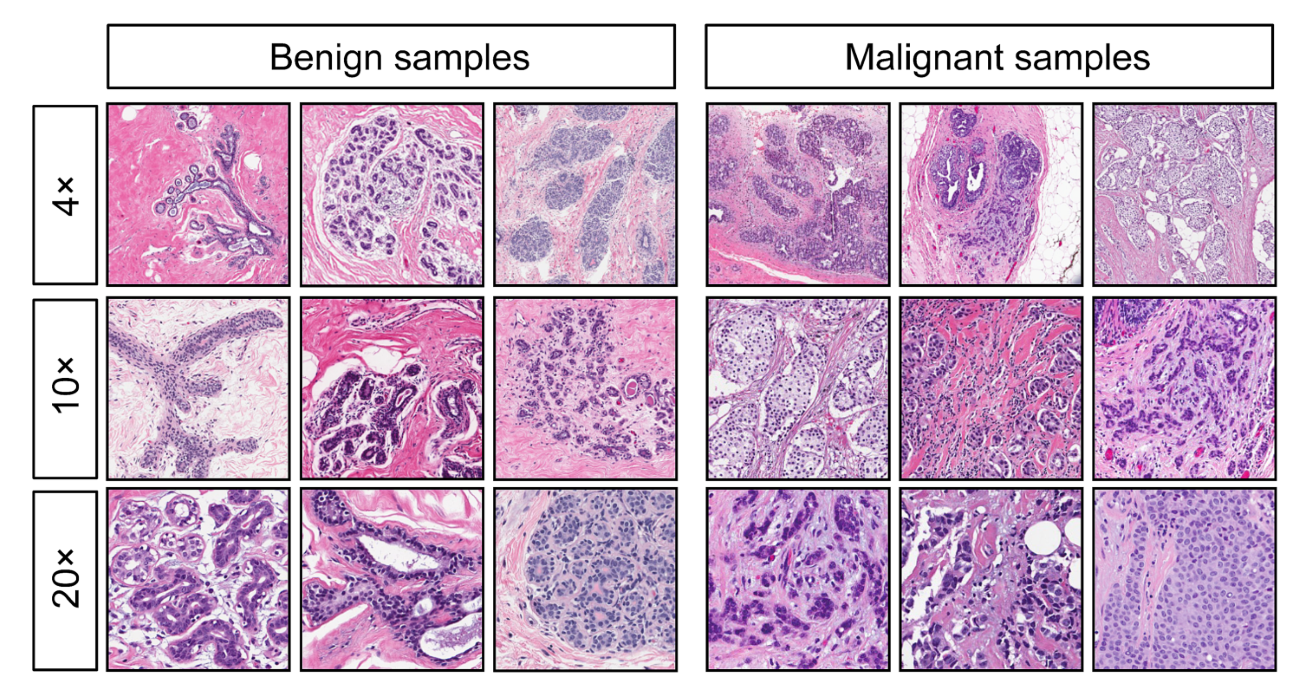

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Carrega o dataset de câncer de mama
data = load_breast_cancer()

# X = dados (atributos das amostras)
X = data.data

# y = alvo (0 = maligno, 1 = benigno)
y = data.target

# Nomes das características
feature_names = data.feature_names

# Cria um DataFrame com os atributos e adiciona a coluna 'target'
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y

# Exibe o DataFrame
df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


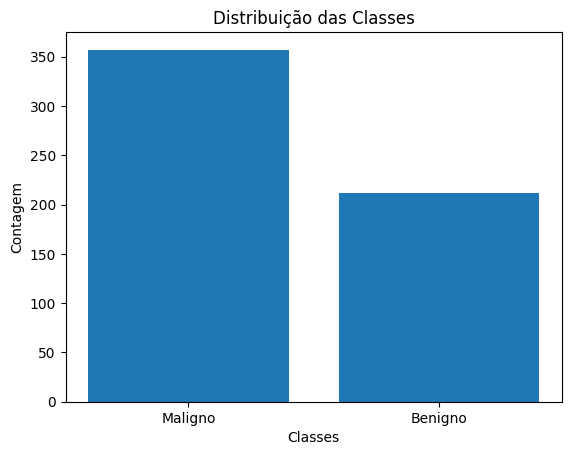

In [2]:
import matplotlib.pyplot as plt

# Conta quantos exemplos existem em cada classe (0 = maligno, 1 = benigno)
class_counts = df['target'].value_counts()

# Define os rótulos das classes
class_labels = ['Maligno','Benigno']

# Cria o gráfico de barras
plt.bar(class_labels, class_counts)
plt.xlabel('Classes')
plt.ylabel('Contagem')
plt.title('Distribuição das Classes')
plt.show()


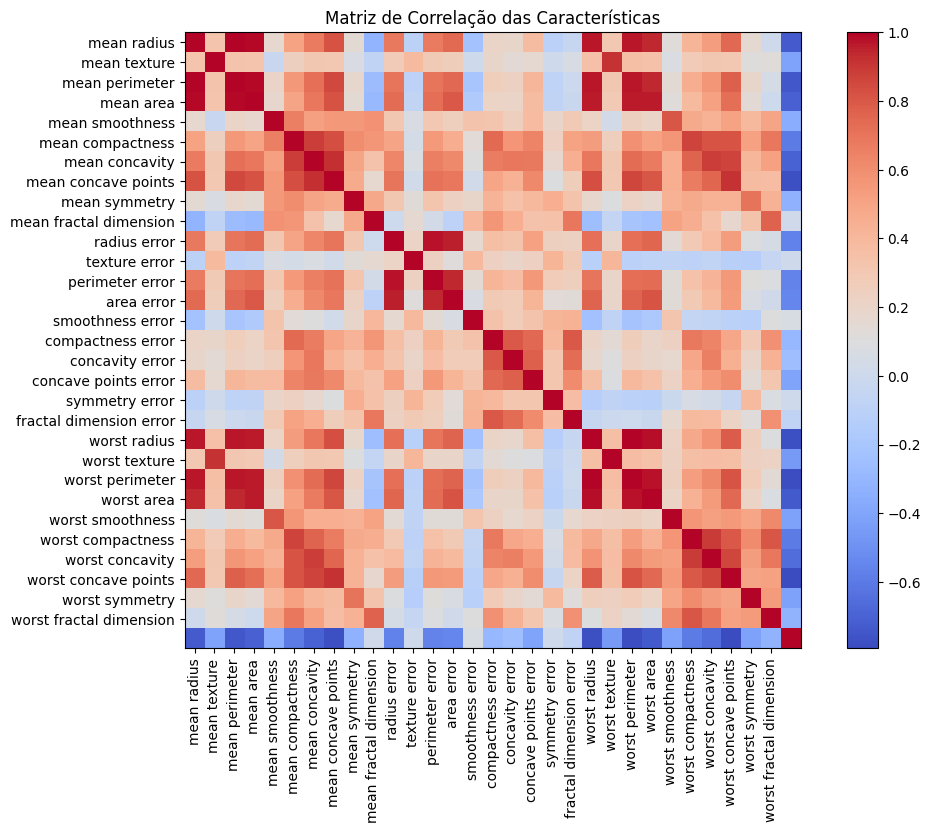

In [3]:
correlation_matrix = df.corr()  # Calcula a correlação entre todas as colunas numéricas

plt.figure(figsize=(12,8))      # Define o tamanho da figura
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')  # Plota a matriz como imagem
plt.colorbar()                  # Adiciona a barra de cores para indicar intensidade da correlação

# Define os rótulos dos eixos com os nomes das variáveis
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)

plt.title('Matriz de Correlação das Características')
plt.show()


- O primeiro gráfico mostra a quantidade de amostras para cada classe do dataset (Maligno e Benigno). Ele nos ajuda a entender como as amostras estão distribuídas entre as classes.
- O segundo gráfico, chamado matriz de correlação, mostra as relações entre as características do dataset. Ele nos ajuda a entender se existe uma relação forte entre as características e se essa relação é positiva (valores próximos de 1) ou negativa (valores próximos de -1). Valores próximos de 0 indicam que não há uma relação forte entre as características. Essa informação nos ajuda a identificar quais características podem ser importantes para a classificação dos dados.

*Os dados foram obtidos por biópsia e exame de imagem (mamografia e ultrassonografia)*

| Número | Característica                    | Descrição                                                                                     |
|--------|-----------------------------------|-----------------------------------------------------------------------------------------------|
| 1      | raio médio do tumor               | Mede o raio médio dos núcleos celulares do tumor                                               |
| 2      | textura média do tumor            | Indica a variação dos valores de cinza nos pixels da imagem do tumor                           |
| 3      | perímetro médio do tumor          | Representa o comprimento médio do contorno do tumor                                           |
| 4      | área média do tumor               | Refere-se à área média ocupada pelo tumor                                                     |
| 5      | suavidade média do tumor          | Mede a variação local nos comprimentos dos raios dos núcleos celulares                         |
| 6      | compactação média do tumor        | Calcula a relação entre o perímetro e a área do tumor                                         |
| 7      | concavidade média do tumor        | Indica a presença e a severidade das partes côncavas no contorno do tumor                      |
| 8      | pontos côncavos médios do tumor   | Mede o número médio de partes côncavas no contorno do tumor                                   |
| 9      | simetria média do tumor           | Avalia a simetria do contorno do tumor                                                        |
| 10     | dimensão fractal média do tumor   | Calcula a complexidade da fronteira do tumor em escala                                        |
| 11     | raio SE (erro padrão)             | Mede a variabilidade do raio dos núcleos celulares                                             |
| 12     | textura SE (erro padrão)          | Indica a variabilidade da textura nos pixels da imagem                                         |
| 13     | perímetro SE (erro padrão)        | Avalia a variabilidade do perímetro do tumor                                                  |
| 14     | área SE (erro padrão)             | Mede a variabilidade da área ocupada pelo tumor                                               |
| 15     | suavidade SE (erro padrão)        | Indica a variabilidade da suavidade local dos raios dos núcleos celulares                      |
| 16     | compactação SE (erro padrão)      | Calcula a variabilidade da compactação do tumor                                               |
| 17     | concavidade SE (erro padrão)      | Mede a variabilidade da presença e severidade das partes côncavas no contorno                  |
| 18     | pontos côncavos SE (erro padrão)   | Indica a variabilidade do número de partes côncavas no contorno                                |
| 19     | simetria SE (erro padrão)         | Avalia a variabilidade da simetria do contorno do tumor                                       |
| 20     | dimensão fractal SE (erro padrão) | Calcula a variabilidade da complexidade da fronteira do tumor em escala                       |
| 21     | raio pior                     | Mede o raio máximo entre todos os núcleos celulares presentes no tumor    |
| 22     | textura pior                  | Indica a textura mais intensa encontrada nos pixels da imagem do tumor    |
| 23     | perímetro pior                | Representa o perímetro máximo entre todos os contornos do tumor          |
| 24     | área pior                     | Refere-se à área máxima ocupada pelo tumor                                |
| 25     | suavidade pior                | Mede a variação local nos comprimentos dos raios dos núcleos celulares no pior caso |
| 26     | compactação pior              | Calcula a relação entre o perímetro e a área do tumor no pior caso        |
| 27     | concavidade pior              | Indica a presença e a severidade das partes côncavas no contorno do tumor no pior caso |
| 28     | pontos côncavos piores        | Mede o número de partes côncavas no contorno do tumor no pior caso        |
| 29     | simetria pior                 | Avalia a simetria do contorno do tumor no pior caso                       |
| 30     | dimensão fractal pior         | Calcula a complexidade da fronteira do tumor em escala no pior caso       |

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carrega o dataset de câncer de mama
data = load_breast_cancer()
feature = data.data       # atributos (características dos tumores)
rotulo = data.target      # alvo (0 = maligno, 1 = benigno)

# Divide em treino (80%) e teste (20%)
features_treino, features_teste, rotulo_treino, rotulo_teste = train_test_split(
    feature, rotulo, test_size=0.2, random_state=42
)

# Normaliza os dados (média=0, desvio padrão=1)
scaler = StandardScaler()
features_treino = scaler.fit_transform(features_treino)
features_teste = scaler.fit_transform(features_teste)

# Define a arquitetura da rede neural
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Dense(units=16, activation='relu', input_shape=(feature.shape[1],)))
modelo.add(tf.keras.layers.Dense(units=16, activation='relu'))
modelo.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))  # saída binária

# Compila o modelo
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treina o modelo
historico = modelo.fit(features_treino, rotulo_treino, batch_size=32, epochs=100,
                       validation_data=(features_teste, rotulo_teste))

# Avalia no conjunto de teste
acc = modelo.evaluate(features_teste, rotulo_teste)
print("Acurácia:", acc)


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Prever novos dados
novos_dados = np.array([[13.1, 20.2, 82.5, 520.1, 0.1, 0.11, 0.12, 0.05, 0.18, 0.07, 0.3, 0.82, 2.5, 30.0, 0.005,
                        15.0, 25.0, 95.0, 600.0, 0.12, 0.13, 0.15, 0.06, 0.2, 0.08, 0.35, 0.9, 2.8, 33.0, 0.007]])

previsoes = modelo.predict(novos_dados)

if previsoes[0] < 0.5:
  print('A pessoa não tem chances de desenvolver câncer de mama')
else:
  print('A pessoa tem chances de desenvolver câncer de mama')

1/1 [==============================] - 0s 108ms/step
A pessoa não tem chances de desenvolver câncer de mama


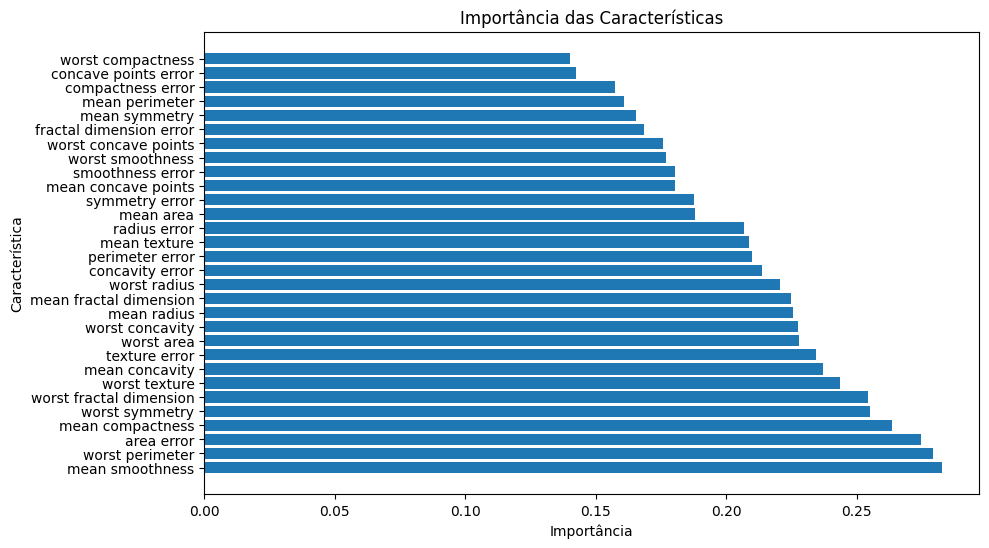

In [ ]:
# Calcula a importância das características com base nos pesos da primeira camada da rede neural
# Pega os pesos da primeira camada (modelo.layers[0].get_weights()[0]),
# tira o valor absoluto (np.abs), faz a média por neurônio (mean(axis=1))
importancias = np.abs(modelo.layers[0].get_weights()[0]).mean(axis=1)

# Obtém os nomes das características do dataset de câncer de mama
nomes_caracteristicas = data.feature_names

# Ordena os índices das importâncias em ordem decrescente
indices_ordenados = np.argsort(importancias)[::-1]

# Reorganiza as importâncias de acordo com os índices ordenados
importancias_ordenadas = importancias[indices_ordenados]

# Reorganiza os nomes das características de acordo com os índices ordenados
nomes_caracteristicas_ordenados = nomes_caracteristicas[indices_ordenados]

# Cria a figura para o gráfico
plt.figure(figsize=(10,6))

# Plota um gráfico de barras horizontais com as importâncias
plt.barh(range(len(nomes_caracteristicas_ordenados)), importancias_ordenadas)

# Define os rótulos do eixo Y como os nomes das características
plt.yticks(range(len(nomes_caracteristicas_ordenados)), nomes_caracteristicas_ordenados)

# Define os rótulos dos eixos e o título do gráfico
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.title('Importância das Características')

# Exibe o gráfico
plt.show()
